## Multiple Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Importing the dataset
df_index = pd.read_csv('Datasets/economic_index.csv')

In [3]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
df_index.drop(columns = ['Unnamed: 0', 'year', 'month'], axis=1, inplace=True)

In [5]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [6]:
# check null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

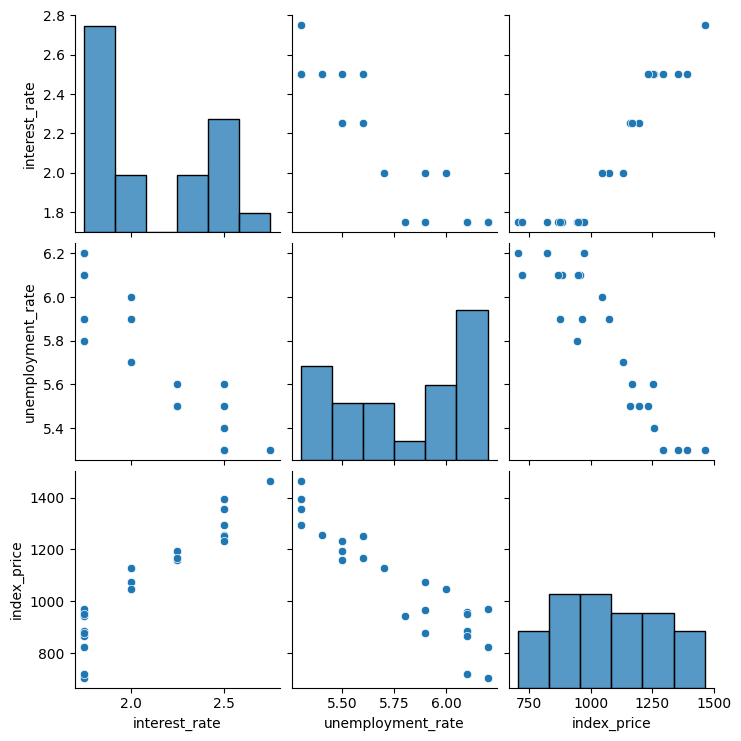

In [7]:
# Let's do some visualizations

import seaborn as sns
sns.pairplot(df_index)

In [8]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


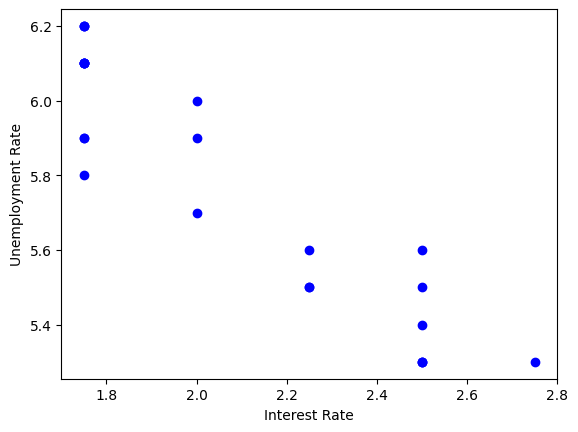

In [9]:
# visulaizing data points more closely

plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color='blue')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')
plt.show()

In [11]:
# independent and dependent features

X = df_index[['interest_rate', 'unemployment_rate']]    # independent features
y = df_index['index_price']  # dependent feature

In [ ]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

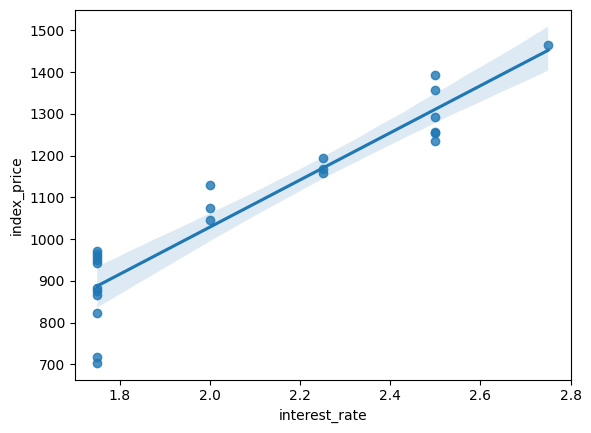

In [14]:
sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])


<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

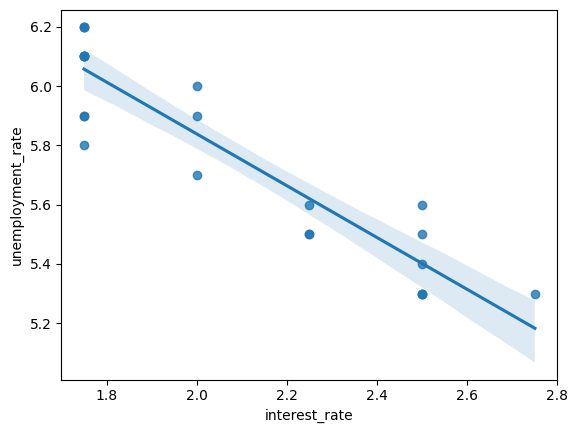

In [15]:
sns.regplot(x=df_index['interest_rate'], y=df_index['unemployment_rate'])

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

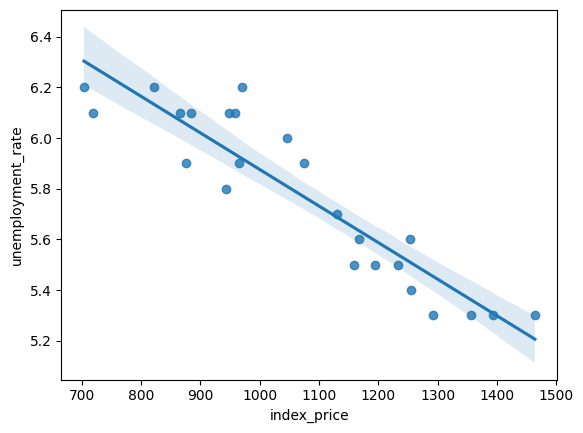

In [16]:
sns.regplot(x=df_index['index_price'], y=df_index['unemployment_rate'])

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [18]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
X_train

array([[ 0.55339859, -0.53244666],
       [-0.9486833 ,  0.41597395],
       [ 1.30443953, -1.48086727],
       [-0.9486833 ,  1.36439457],
       [ 1.30443953, -0.53244666],
       [ 1.30443953, -1.48086727],
       [-0.19764235,  0.73211416],
       [-0.9486833 ,  1.04825436],
       [ 1.30443953, -1.48086727],
       [ 1.30443953, -1.16472707],
       [-0.9486833 ,  1.36439457],
       [-0.9486833 ,  1.04825436],
       [-0.9486833 ,  0.41597395],
       [-0.9486833 ,  1.04825436],
       [ 0.55339859, -0.84858687],
       [-0.19764235, -0.21630646],
       [-0.9486833 ,  0.09983375],
       [-0.9486833 ,  1.04825436],
       [ 1.30443953, -0.84858687]])

In [20]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()


In [21]:
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(regressor, X_train, y_train, scoring="neg_mean_squared_error", cv=3)
print("Cross-validation scores:", scores)

Cross-validation scores: [-4304.75412833 -7608.56499271 -5108.77588052]


In [25]:
np.mean(scores)

np.float64(-5674.031667186762)

In [27]:
# prediction
y_pred = regressor.predict(X_test)
y_pred

array([1204.14403741,  821.62603274, 1406.38534684,  857.68137178,
        994.85736555])

In [28]:
# Performance Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 6957.105303258833
Mean Absolute Error: 71.71878409976625
R-squared: 0.8254940547158576
Root Mean Squared Error: 83.40926389351985


In [30]:
# Adjusted R-squared Score

R_squared_score = (1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))
print("Adjusted R-squared:", R_squared_score)

Adjusted R-squared: 0.6509881094317151


### Assumptions

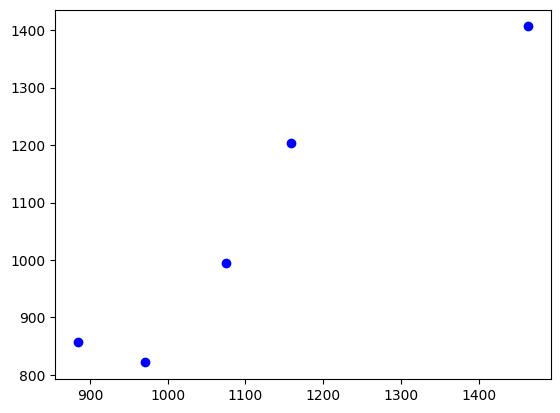

In [31]:
plt.scatter(y_test, y_pred, color='blue')


In [32]:
residuals = y_test - y_pred
print("Residuals:", residuals)

Residuals: 8     -45.144037
16    149.373967
0      57.614653
18     26.318628
11     80.142634
Name: index_price, dtype: float64


<Axes: xlabel='index_price', ylabel='Density'>

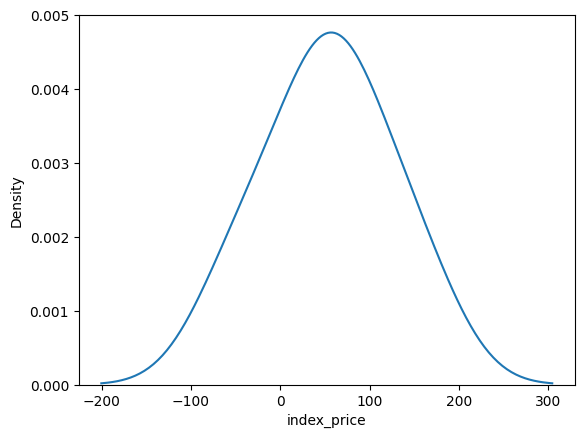

In [37]:
# plotting the residual
sns.kdeplot(residuals)

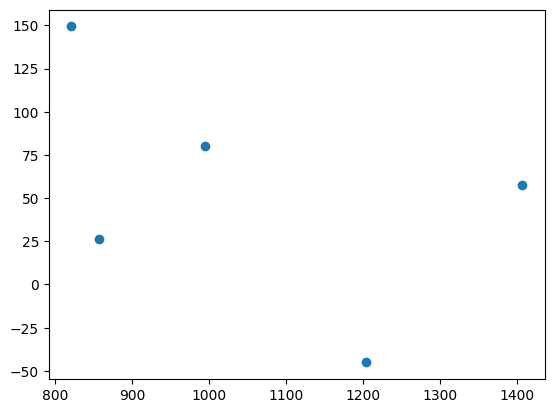

In [38]:
plt.scatter(y_pred, residuals)

Since data is uniformly distributed, I can conclude that there is no problem with data.

In [39]:
# OLS Linear Model
import statsmodels.api as sm
model = sm.OLS(y_train, X_train).fit()

In [40]:
model.summary()

c:\codingprojects\MLAlgorithms\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.081
Method:                 Least Squares   F-statistic:                             0.2916
Date:                Wed, 15 Apr 2026   Prob (F-statistic):                       0.751
Time:                        03:45:18   Log-Likelihood:                         -159.34
No. Observations:                  19   AIC:                                      322.7
Df Residuals:                      17   BIC:                                      324.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            86.6335    647.232      0.134      0.895   -1278.906    1452.173
x2          -114.0486    647.232     -0.176      0.862   -1479.588    1251.491
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.526
Skew:                          -0.369   Prob(JB):                        0.769
Kurtosis:                       2.656   Cond. No.                         4.82
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [41]:
regressor.coef_

array([  86.63351334, -114.04857249])